<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_11_Random_Signals_%26_Power_Spectral_Density_(PSD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Stochastic processes, autocorrelation, periodograms, and Welch’s method for spectral estimation.

The Project: Build a radar/sonar target detector that pulls weak periodic reflection signals out of overwhelming white Gaussian noise.

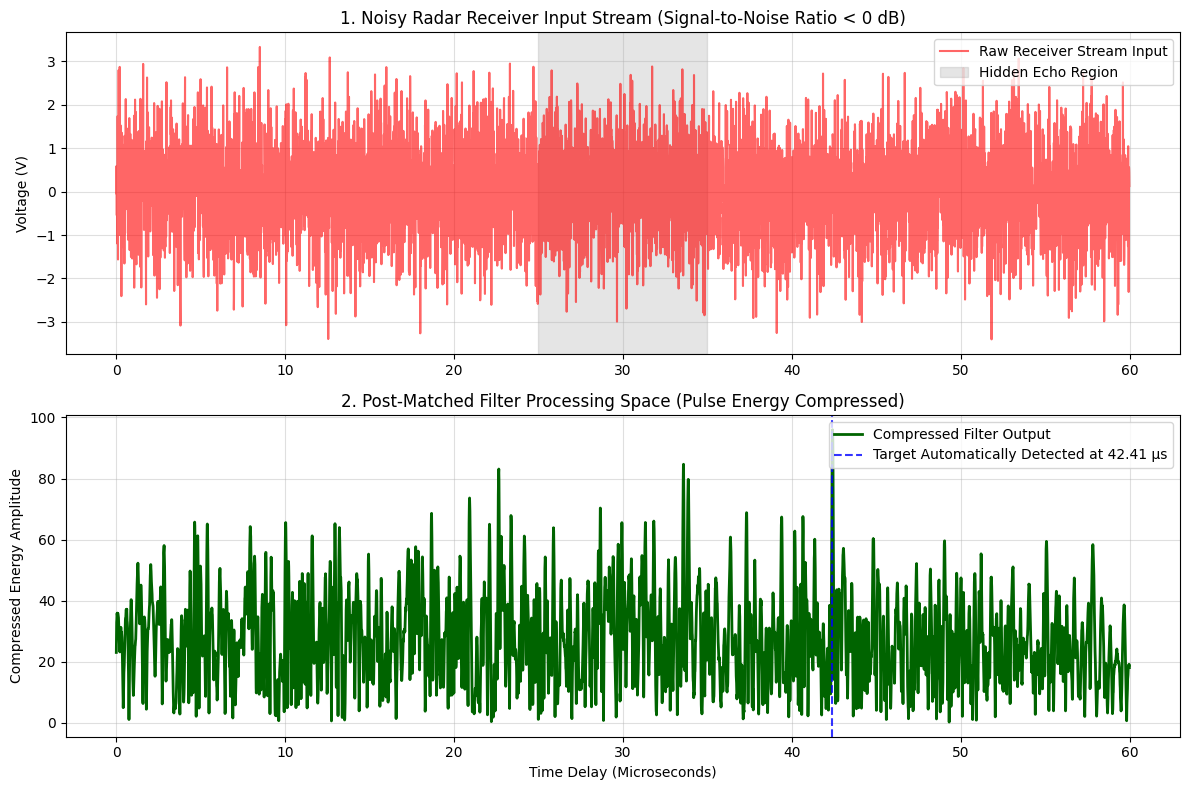

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def run_radar_target_detector():
    # --- 1. RADAR HARDWARE CONFIGURATION ---
    fs = 100e6          # Sampling Frequency (100 MHz clock rate)
    pulse_duration = 10e-6 # Transmitted pulse width (10 microseconds)
    f_start = 5e6       # Chirp start frequency (5 MHz)
    f_end = 15e6        # Chirp end frequency (15 MHz)

    # Generate the local replica reference template of the transmitted chirp
    t_pulse = np.arange(0, pulse_duration, 1/fs)
    tx_chirp = signal.chirp(t_pulse, f0=f_start, t1=pulse_duration, f1=f_end, method='linear')

    # --- 2. ENVIRONMENT MODELING (THE TARGET RETURN) ---
    total_time = 60e-6  # Total simulation window scope (60 microseconds)
    t_timeline = np.arange(0, total_time, 1/fs)
    received_stream = np.zeros_like(t_timeline)

    # Place a hidden target reflection at a specific time delay (e.g., 25 microseconds)
    target_delay_samples = int(25e-6 * fs)
    attenuation = 0.05   # Severe atmospheric/scattering signal power loss

    # Insert weak echo copy into the timeline
    received_stream[target_delay_samples : target_delay_samples + len(tx_chirp)] = tx_chirp * attenuation

    # Inject devastating Additive White Gaussian Noise (AWGN)
    # The noise variance is intentionally set higher than the echo amplitude
    noise = np.random.normal(0, 1.0, len(t_timeline))
    corrupted_stream = received_stream + noise

    # --- 3. THE MATCHED FILTER PROCESSING LAYER ---
    # Time-reversing the local template creates the matched filter impulse response
    matched_filter_kernel = tx_chirp[::-1]

    # Convolve the noisy stream with our matched filter kernel
    # Using mode='same' preserves alignment with the input timeline
    detector_output = signal.convolve(corrupted_stream, matched_filter_kernel, mode='same')

    # Calculate analytical envelope using the Hilbert Transform to isolate real power spikes
    analytic_signal = signal.hilbert(detector_output)
    amplitude_envelope = np.abs(analytic_signal)

    # --- 4. SIGNAL OBSERVATION VISUALIZATION ---
    plt.figure(figsize=(12, 8))

    # Top Plot: Raw Data Ingestion Stream
    plt.subplot(2, 1, 1)
    plt.plot(t_timeline * 1e6, corrupted_stream, color='red', alpha=0.6, label='Raw Receiver Stream Input')
    plt.axvspan(25, 35, color='gray', alpha=0.2, label='Hidden Echo Region')
    plt.title("1. Noisy Radar Receiver Input Stream (Signal-to-Noise Ratio < 0 dB)")
    plt.ylabel("Voltage (V)")
    plt.grid(True, alpha=0.4)
    plt.legend(loc="upper right")

    # Bottom Plot: Matched Filter Output Space
    plt.subplot(2, 1, 2)
    plt.plot(t_timeline * 1e6, amplitude_envelope, color='darkgreen', linewidth=2, label='Compressed Filter Output')
    # Convert samples back to absolute range time peak
    peak_idx = np.argmax(amplitude_envelope)
    detected_time_us = t_timeline[peak_idx] * 1e6

    plt.axvline(x=detected_time_us, color='blue', linestyle='--', alpha=0.8,
                    label=f'Target Automatically Detected at {detected_time_us:.2f} µs')

    plt.title("2. Post-Matched Filter Processing Space (Pulse Energy Compressed)")
    plt.xlabel("Time Delay (Microseconds)")
    plt.ylabel("Compressed Energy Amplitude")
    plt.grid(True, alpha=0.4)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# Run the target detector
run_radar_target_detector()